Notebook exploración de datos inicial

In [7]:
# Importación de librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [8]:
# Instanciamos el conjunto de datos en un DataFrame
df = pd.read_csv("../../data/raw/dataset_practica_final.csv")

In [9]:
# Mostramos las primeras filas del DataFrame
df.head()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [10]:
df.tail(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119380,City Hotel,0,44,2017,August,35,31,1,3,2,...,No Deposit,9.0,NaN,0,Transient,140.75,0,1,Check-Out,2017-09-04
119381,City Hotel,0,188,2017,August,35,31,2,3,2,...,No Deposit,14.0,NaN,0,Transient,99.00,0,0,Check-Out,2017-09-05
119382,City Hotel,0,135,2017,August,35,30,2,4,3,...,No Deposit,7.0,NaN,0,Transient,209.00,0,0,Check-Out,2017-09-05
119383,City Hotel,0,164,2017,August,35,31,2,4,2,...,No Deposit,42.0,NaN,0,Transient,87.60,0,0,Check-Out,2017-09-06
119384,City Hotel,0,21,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,2,Check-Out,2017-09-06
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


In [11]:
# Mostramos información del DataFrame con todas sus columnas    
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [12]:
# Mostramos las dimensiones del DataFrame
df.shape

(119390, 32)

In [13]:
# Descripción estadística de las columnas numéricas. Utilizamos el transpose para visualizar información de manera más clara, desglosada por variables
df.describe(include='number').transpose()



,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [14]:
# Descripción estadística de las columnas categóricas.
df.describe(include='object').transpose()

,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


In [15]:
# No se requiere limpieza de nombres de variables, ya que están todas en mayúsculas sin caracteres especiales

# Haremos limpieza de algunos datos que podrían resultar problemáticos:
# reservation_status seguramente será redundante con is_canceled
# Mostramos todas las posibles combinaciones de valores en la columna reservation_status y is_canceled
df.groupby(['reservation_status', 'is_canceled']).size()



reservation_status  is_canceled
Canceled            1              43017
Check-Out           0              75166
No-Show             1               1207
dtype: int64

In [16]:
# La columna "reservation_status" resulta ser más interesante de lo que parecía, ya que contempla una distincion entre "cancelled" (preaviso) y "no show" (sin preaviso) 
# Será nuestra columna target
target_column='reservation_status'

# Seleccionamos las columnas independientes
list_columnas_independientes = df.drop(columns=target_column).columns.to_list()

# obtenemos las columnas numéricas
columnas_numericas = df.select_dtypes(include=['number']).columns.tolist()

# obtenemos las columnas categóricas
columnas_categoricas = df.drop(columns=target_column).select_dtypes(include=['object']).columns.tolist()




In [17]:
# Analizamos los nulos, centrandonos en los que sí tienen nulos
df.isnull().sum()[df.isnull().sum() > 0]

children         4
country        488
agent        16340
company     112593
dtype: int64

In [18]:
# En el caso de children, podemos asumir que los nulos representan que no hay niños en la reserva. Establecemos el valor 0
df['children'] = df['children'].fillna(0)

# El caso de agent y company, se esperan nulos, por lo que convertiremos al valor "(Sin especificar)"
df['agent'] = df['agent'].fillna("(Sin especificar)")
df['company'] = df['company'].fillna("(Sin especificar)")

#Nos asegurmaos de 'agent' y 'company' estén en la lista de columnas categoricas
columnas_numericas = [col for col in columnas_numericas if col not in ['agent', 'company']]
columnas_categoricas = columnas_categoricas + [col for col in ['agent', 'company'] if col not in columnas_categoricas]




In [19]:
# El caso del pais puede ser problemático, por lo que trabajaremos con 2 DataFrames para analizar todas las posibles casuísticas: uno suprimiendo los nulos y otro transformandonos los nulos a un valor especifico "(Sin especificar)"

# DataFrame suprimiendo los nulos
df_sin_nulos = df.dropna()

# DataFrame transformando los nulos a un valor específico
df_con_nulos_transformados = df.copy()
# Transformamos los nulos en las variables numéricas a 0
num_cols = df_con_nulos_transformados.select_dtypes(include=['number']).columns
df_con_nulos_transformados[num_cols] = df_con_nulos_transformados[num_cols].fillna(0)
# Transformamos los nulos en las variables categóricas a "(Sin especificar)"
cat_cols = df_con_nulos_transformados.select_dtypes(include=['object']).columns
df_con_nulos_transformados[cat_cols] = df_con_nulos_transformados[cat_cols].fillna("(Sin especificar)") 

# Verificamos el shape de los DataFrames resultantes
print("Shape del DataFrame sin nulos = ", df_sin_nulos.shape)
print("Shape del DataFrame con nulos transformados = ", df_con_nulos_transformados.shape)



Shape del DataFrame sin nulos =  (118902, 32)
Shape del DataFrame con nulos transformados =  (119390, 32)


In [20]:
# La diferencia de tamaño no es significativa. Country "nulo" podría ser ruido o datos faltantes no críticos. Analizaremos ambos conjuntos de datos

# Verificamos si hay valores duplicados en el DataFrame
print ("Duplicados en origen = ",df.duplicated().sum())
print ("Duplicados sin nulos = ",df_sin_nulos.duplicated().sum())
print ("Duplicados con nulos transformados = ",df_con_nulos_transformados.duplicated().sum())

Duplicados en origen =  31994
Duplicados sin nulos =  31958
Duplicados con nulos transformados =  31994


In [21]:
# Desdoblamos de nuevo el conjunto de datos
df_sin_nulos_y_sin_duplicados = df_sin_nulos.drop_duplicates()
df_con_nulos_transformados_sin_duplicados = df_con_nulos_transformados.drop_duplicates()
print ("Duplicados sin nulos después de eliminar = ",df_sin_nulos_y_sin_duplicados.duplicated().sum())
print ("Duplicados con nulos transformados después de eliminar = ",df_con_nulos_transformados_sin_duplicados.duplicated().sum())

print("Shape del DataFrame original = ", df.shape)
print("Shape del DataFrame sin nulos = ", df_sin_nulos.shape)
print("Shape del DataFrame con nulos transformados = ", df_con_nulos_transformados.shape)
print("Shape del DataFrame sin nulos y sin duplicados = ", df_sin_nulos_y_sin_duplicados.shape)
print("Shape del DataFrame con nulos transformados y sin duplicados = ", df_con_nulos_transformados_sin_duplicados.shape)


Duplicados sin nulos después de eliminar =  0
Duplicados con nulos transformados después de eliminar =  0
Shape del DataFrame original =  (119390, 32)
Shape del DataFrame sin nulos =  (118902, 32)
Shape del DataFrame con nulos transformados =  (119390, 32)
Shape del DataFrame sin nulos y sin duplicados =  (86944, 32)
Shape del DataFrame con nulos transformados y sin duplicados =  (87396, 32)


In [22]:
# El DataFrame final sin duplicados tiene suficientes datos. No obstante, analizaremos ambos conjuntos de datos.

# Obtenemos las frecuencias absolutas de la columna target, en cada DataFrame
print("\nFrecuencias absolutas de la columna target en df_sin_nulos:\n")
print(df_sin_nulos[target_column].value_counts())
print("\nFrecuencias absolutas de la columna target en df_con_nulos_transformados:\n")
print(df_con_nulos_transformados[target_column].value_counts())
print("\nFrecuencias absolutas de la columna target en df_sin_nulos_y_sin_duplicados:\n")
print(df_sin_nulos_y_sin_duplicados[target_column].value_counts())
print("\nFrecuencias absolutas de la columna target en df_con_nulos_transformados_sin_duplicados:\n")
print(df_con_nulos_transformados_sin_duplicados[target_column].value_counts())


Frecuencias absolutas de la columna target en df_sin_nulos:

reservation_status
Check-Out    74745
Canceled     42954
No-Show       1203
Name: count, dtype: int64

Frecuencias absolutas de la columna target en df_con_nulos_transformados:

reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64

Frecuencias absolutas de la columna target en df_sin_nulos_y_sin_duplicados:

reservation_status
Check-Out    62953
Canceled     22981
No-Show       1010
Name: count, dtype: int64

Frecuencias absolutas de la columna target en df_con_nulos_transformados_sin_duplicados:

reservation_status
Check-Out    63371
Canceled     23011
No-Show       1014
Name: count, dtype: int64


In [23]:
# Obtenemos las frecuencias relativas de la columna target, en cada DataFrame
print("\nFrecuencias relativas de la columna target en df_sin_nulos:\n")
print(df_sin_nulos[target_column].value_counts(normalize=True))
print("\nFrecuencias relativas de la columna target en df_con_nulos_transformados:\n")
print(df_con_nulos_transformados[target_column].value_counts(normalize=True))
print("\nFrecuencias relativas de la columna target en df_sin_nulos_y_sin_duplicados:\n")
print(df_sin_nulos_y_sin_duplicados[target_column].value_counts(normalize=True))
print("\nFrecuencias relativas de la columna target en df_con_nulos_transformados_sin_duplicados:\n")
print(df_con_nulos_transformados_sin_duplicados[target_column].value_counts(normalize=True))


Frecuencias relativas de la columna target en df_sin_nulos:

reservation_status
Check-Out    0.628627
Canceled     0.361255
No-Show      0.010118
Name: proportion, dtype: float64

Frecuencias relativas de la columna target en df_con_nulos_transformados:

reservation_status
Check-Out    0.629584
Canceled     0.360307
No-Show      0.010110
Name: proportion, dtype: float64

Frecuencias relativas de la columna target en df_sin_nulos_y_sin_duplicados:

reservation_status
Check-Out    0.724064
Canceled     0.264320
No-Show      0.011617
Name: proportion, dtype: float64

Frecuencias relativas de la columna target en df_con_nulos_transformados_sin_duplicados:

reservation_status
Check-Out    0.725102
Canceled     0.263296
No-Show      0.011602
Name: proportion, dtype: float64


# Analisis df_sin_nulos

In [ ]:
# Visualización de las variables numéricas con un gráfico de dispersión distinguiendo por la clase
#sns.pairplot(df_sin_nulos, hue=target_column, palette='Set1')

##pendiente de procesar porque me colapsa el ordenador -- serpegon11710-byte

In [25]:
# Preparación de los datos para el modelo de regresión logística
X_sin_nulos = df_sin_nulos[list_columnas_independientes]
y_sin_nulos = df_sin_nulos[target_column]

In [26]:

# División de los datos en conjuntos de entrenamiento y prueba
X_train_sin_nulos, X_test_sin_nulos, y_train_sin_nulos, y_test_sin_nulos = train_test_split(X_sin_nulos, y_sin_nulos, test_size=.2, random_state=422)

In [84]:

X_train_sin_nulos_procesado = X_train_sin_nulos.copy()
X_test_sin_nulos_procesado = X_test_sin_nulos.copy()

# Convertimos las variables categóricas (texto) a dummies (0 y 1)
X_train_sin_nulos_procesado = pd.get_dummies(X_train_sin_nulos_procesado, drop_first=True)
X_test_sin_nulos_procesado = pd.get_dummies(X_test_sin_nulos_procesado, drop_first=True)

# Aseguramos que las columnas del conjunto de prueba coincidan con las del conjunto de entrenamiento
X_test_sin_nulos_procesado = X_test_sin_nulos_procesado.reindex(columns=X_train_sin_nulos_procesado.columns, fill_value=0)

## DEBUG: Imprimimos las columnas y su estado antes de escalar y procesar
## print("Columnas numéricas:")
## print(columnas_numericas)
## print("Columnas categóricas:")
## print(columnas_categoricas)
## print("Columnas procesadas:")
## print(X_train_sin_nulos_procesado.columns.tolist())
## print("Columnas del conjunto de prueba procesado:")
## print(X_test_sin_nulos_procesado.columns.tolist())

# Escalamos las numéricas usando esa lista sobre nuestro DataFrame de trabajo
scaler_sin_nulos = StandardScaler()
X_train_sin_nulos_procesado[columnas_numericas] = scaler_sin_nulos.fit_transform(X_train_sin_nulos_procesado[columnas_numericas])
X_test_sin_nulos_procesado[columnas_numericas] = scaler_sin_nulos.transform(X_test_sin_nulos_procesado[columnas_numericas])


# Creación del modelo de regresión logística 
modelo_rl_sin_nulos = LogisticRegression(max_iter=200, random_state=42)   
modelo_rl_sin_nulos.fit(X_train_sin_nulos_procesado, y_train_sin_nulos)

# Obtenemos la predicción del modelo
y_pred_sin_nulos = modelo_rl_sin_nulos.predict(X_test_sin_nulos_procesado)

# Evaluamos el modelo usando el accuracy (exactitud)
accuracy_sin_nulos = accuracy_score(y_test_sin_nulos, y_pred_sin_nulos)
print(f"Accuracy del modelo sin nulos: {accuracy_sin_nulos:.4f}")



Accuracy del modelo sin nulos: 0.9911


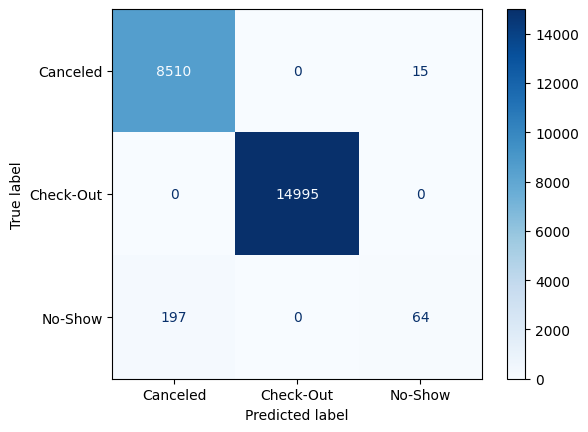

In [30]:
# Generamos la matriz de confusión 
cm_sin_nulos = confusion_matrix(y_test_sin_nulos, y_pred_sin_nulos)
disp_sin_nulos = ConfusionMatrixDisplay(confusion_matrix=cm_sin_nulos, display_labels=modelo_rl_sin_nulos.classes_)
disp_sin_nulos.plot(cmap="Blues")

# Analisis df_con_nulos_transformados

In [65]:
# Visualización de las variables numéricas con un gráfico de dispersión distinguiendo por la clase
#sns.pairplot(df_con_nulos_transformados, hue=target_column, palette='Set1')

##pendiente de procesar porque me colapsa el ordenador -- serpegon11710-byte

In [61]:
# Preparación de los datos para el modelo de regresión logística
X_con_nulos_transformados = df_con_nulos_transformados[list_columnas_independientes]
y_con_nulos_transformados = df_con_nulos_transformados[target_column]

In [62]:
# División de los datos con nulos transformados en conjuntos de entrenamiento y prueba
X_train_con_nulos_transformados, X_test_con_nulos_transformados, y_train_con_nulos_transformados, y_test_con_nulos_transformados = train_test_split(X_con_nulos_transformados, y_con_nulos_transformados, test_size=.2, random_state=422)

In [69]:
X_train_con_nulos_transformados_procesado = X_train_con_nulos_transformados.copy()
X_test_con_nulos_transformados_procesado = X_test_con_nulos_transformados.copy()

# Convertimos las variables categóricas (texto) a dummies (0 y 1)
X_train_con_nulos_transformados_procesado = pd.get_dummies(X_train_con_nulos_transformados_procesado, drop_first=True)
X_test_con_nulos_transformados_procesado = pd.get_dummies(X_test_con_nulos_transformados_procesado, drop_first=True)

# Aseguramos que las columnas del conjunto de prueba coincidan con las del conjunto de entrenamiento
X_test_con_nulos_transformados_procesado = X_test_con_nulos_transformados_procesado.reindex(columns=X_train_con_nulos_transformados_procesado.columns, fill_value=0)

## DEBUG: Imprimimos las columnas y su estado antes de escalar y procesar
## print("Columnas numéricas:")
## print(columnas_numericas)
## print("Columnas categóricas:")
## print(columnas_categoricas)
## print("Columnas procesadas:")
## print(X_train_con_nulos_transformados_procesado.columns.tolist())
## print("Columnas del conjunto de prueba procesado:")
## print(X_test_con_nulos_transformados_procesado.columns.tolist())

# Escalamos las numéricas usando esa lista sobre nuestro DataFrame de trabajo
scaler_con_nulos_transformados = StandardScaler()
X_train_con_nulos_transformados_procesado[columnas_numericas] = scaler_con_nulos_transformados.fit_transform(X_train_con_nulos_transformados_procesado[columnas_numericas])
X_test_con_nulos_transformados_procesado[columnas_numericas] = scaler_con_nulos_transformados.transform(X_test_con_nulos_transformados_procesado[columnas_numericas]) 


# Creación del modelo de regresión logística 
modelo_rl_con_nulos_transformados = LogisticRegression(max_iter=200, random_state=42)   
modelo_rl_con_nulos_transformados.fit(X_train_con_nulos_transformados_procesado, y_train_con_nulos_transformados)

# Obtenemos la predicción del modelo
y_pred_con_nulos_transformados = modelo_rl_con_nulos_transformados.predict(X_test_con_nulos_transformados_procesado)

# Evaluamos el modelo usando el accuracy (exactitud)
accuracy_con_nulos_transformados = accuracy_score(y_test_con_nulos_transformados, y_pred_con_nulos_transformados)
print(f"Accuracy del modelo con nulos transformados: {accuracy_con_nulos_transformados:.4f}")


Accuracy del modelo con nulos transformados: 0.9914


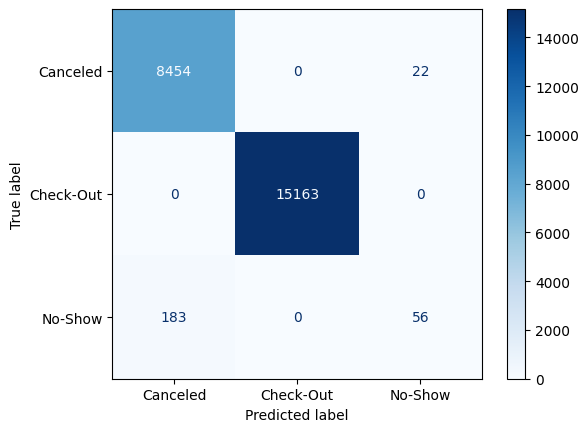

In [70]:
# Generamos la matriz de confusión 
cm_con_nulos_transformados = confusion_matrix(y_test_con_nulos_transformados, y_pred_con_nulos_transformados)
disp_con_nulos_transformados = ConfusionMatrixDisplay(confusion_matrix=cm_con_nulos_transformados, display_labels=modelo_rl_con_nulos_transformados.classes_)
disp_con_nulos_transformados.plot(cmap="Blues")

# Analisis df_sin_nulos_y_sin_duplicados

In [72]:
# Visualización de las variables numéricas con un gráfico de dispersión distinguiendo por la clase
#sns.pairplot(df_sin_nulos_y_sin_duplicados, hue=target_column, palette='Set1')

##pendiente de procesar porque me colapsa el ordenador -- serpegon11710-byte

In [73]:
# Preparación de los datos para el modelo de regresión logística
X_sin_nulos_y_sin_duplicados = df_sin_nulos_y_sin_duplicados[list_columnas_independientes]
y_sin_nulos_y_sin_duplicados = df_sin_nulos_y_sin_duplicados[target_column]

In [74]:
# División de los datos en conjuntos de entrenamiento y prueba
X_train_sin_nulos_y_sin_duplicados, X_test_sin_nulos_y_sin_duplicados, y_train_sin_nulos_y_sin_duplicados, y_test_sin_nulos_y_sin_duplicados = train_test_split(X_sin_nulos_y_sin_duplicados, y_sin_nulos_y_sin_duplicados, test_size=.2, random_state=422)

In [75]:
X_train_sin_nulos_y_sin_duplicados_procesado = X_train_sin_nulos_y_sin_duplicados.copy()
X_test_sin_nulos_y_sin_duplicados_procesado = X_test_sin_nulos_y_sin_duplicados.copy()

# Convertimos las variables categóricas (texto) a dummies (0 y 1)
X_train_sin_nulos_y_sin_duplicados_procesado = pd.get_dummies(X_train_sin_nulos_y_sin_duplicados_procesado, drop_first=True)
X_test_sin_nulos_y_sin_duplicados_procesado = pd.get_dummies(X_test_sin_nulos_y_sin_duplicados_procesado, drop_first=True)

# Aseguramos que las columnas del conjunto de prueba coincidan con las del conjunto de entrenamiento
X_test_sin_nulos_y_sin_duplicados_procesado = X_test_sin_nulos_y_sin_duplicados_procesado.reindex(columns=X_train_sin_nulos_y_sin_duplicados_procesado.columns, fill_value=0)

## DEBUG: Imprimimos las columnas y su estado antes de escalar y procesar
## print("Columnas numéricas:")
## print(columnas_numericas)
## print("Columnas categóricas:")
## print(columnas_categoricas)
## print("Columnas procesadas:")
## print(X_train_sin_nulos_y_sin_duplicados_procesado.columns.tolist())
## print("Columnas del conjunto de prueba procesado:")
## print(X_test_sin_nulos_y_sin_duplicados_procesado.columns.tolist())

# Escalamos las numéricas usando esa lista sobre nuestro DataFrame de trabajo
scaler_sin_nulos_y_sin_duplicados = StandardScaler()
X_train_sin_nulos_y_sin_duplicados_procesado[columnas_numericas] = scaler_sin_nulos_y_sin_duplicados.fit_transform(X_train_sin_nulos_y_sin_duplicados_procesado[columnas_numericas])
X_test_sin_nulos_y_sin_duplicados_procesado[columnas_numericas] = scaler_sin_nulos_y_sin_duplicados.transform(X_test_sin_nulos_y_sin_duplicados_procesado[columnas_numericas])


# Creación del modelo de regresión logística 
modelo_rl_sin_nulos_y_sin_duplicados = LogisticRegression(max_iter=200, random_state=42)   
modelo_rl_sin_nulos_y_sin_duplicados.fit(X_train_sin_nulos_y_sin_duplicados_procesado, y_train_sin_nulos_y_sin_duplicados)

# Obtenemos la predicción del modelo
y_pred_sin_nulos_y_sin_duplicados = modelo_rl_sin_nulos_y_sin_duplicados.predict(X_test_sin_nulos_y_sin_duplicados_procesado)

# Evaluamos el modelo usando el accuracy (exactitud)
accuracy_sin_nulos_y_sin_duplicados = accuracy_score(y_test_sin_nulos_y_sin_duplicados, y_pred_sin_nulos_y_sin_duplicados)
print(f"Accuracy del modelo sin nulos y sin duplicados: {accuracy_sin_nulos_y_sin_duplicados:.4f}")

Accuracy del modelo sin nulos y sin duplicados: 0.9884


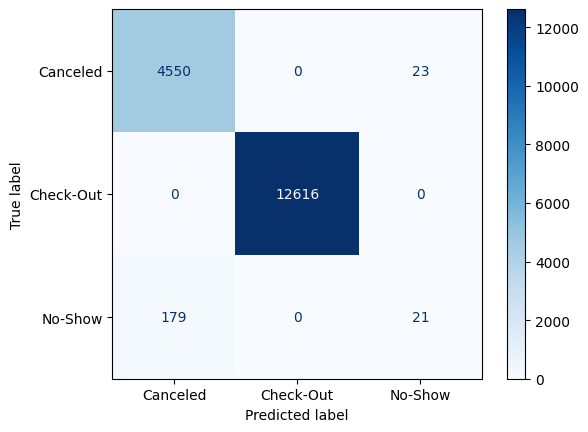

In [76]:
# Generamos la matriz de confusión 
cm_sin_nulos_y_sin_duplicados = confusion_matrix(y_test_sin_nulos_y_sin_duplicados, y_pred_sin_nulos_y_sin_duplicados)
disp_sin_nulos_y_sin_duplicados = ConfusionMatrixDisplay(confusion_matrix=cm_sin_nulos_y_sin_duplicados, display_labels=modelo_rl_sin_nulos_y_sin_duplicados.classes_)
disp_sin_nulos_y_sin_duplicados.plot(cmap="Blues")

In [ ]:
# Analisis df_con_nulos_sin_duplicadostransformados

In [77]:
# Visualización de las variables numéricas con un gráfico de dispersión distinguiendo por la clase
#sns.pairplot(df_con_nulos_sin_duplicados_transformados, hue=target_column, palette='Set1')

##pendiente de procesar porque me colapsa el ordenador -- serpegon11710-byte

In [78]:
# Preparación de los datos para el modelo de regresión logística
X_con_nulos_transformados_sin_duplicados = df_con_nulos_transformados_sin_duplicados[list_columnas_independientes]
y_con_nulos_transformados_sin_duplicados = df_con_nulos_transformados_sin_duplicados[target_column]


In [79]:
# División de los datos con nulos transformados en conjuntos de entrenamiento y prueba
X_train_con_nulos_transformados_sin_duplicados, X_test_con_nulos_transformados_sin_duplicados, y_train_con_nulos_transformados_sin_duplicados, y_test_con_nulos_transformados_sin_duplicados = train_test_split(X_con_nulos_transformados_sin_duplicados, y_con_nulos_transformados_sin_duplicados, test_size=.2, random_state=422)

In [80]:
X_train_con_nulos_transformados_sin_duplicados_procesado = X_train_con_nulos_transformados_sin_duplicados.copy()
X_test_con_nulos_transformados_sin_duplicados_procesado = X_test_con_nulos_transformados_sin_duplicados.copy()

# Convertimos las variables categóricas (texto) a dummies (0 y 1)
X_train_con_nulos_transformados_sin_duplicados_procesado = pd.get_dummies(X_train_con_nulos_transformados_sin_duplicados_procesado, drop_first=True)
X_test_con_nulos_transformados_sin_duplicados_procesado = pd.get_dummies(X_test_con_nulos_transformados_sin_duplicados_procesado, drop_first=True)

# Aseguramos que las columnas del conjunto de prueba coincidan con las del conjunto de entrenamiento
X_test_con_nulos_transformados_sin_duplicados_procesado = X_test_con_nulos_transformados_sin_duplicados_procesado.reindex(columns=X_train_con_nulos_transformados_sin_duplicados_procesado.columns, fill_value=0)

## DEBUG: Imprimimos las columnas y su estado antes de escalar y procesar
## print("Columnas numéricas:")
## print(columnas_numericas)
## print("Columnas categóricas:")
## print(columnas_categoricas)
## print("Columnas procesadas:")
## print(X_train_con_nulos_transformados_sin_duplicados_procesado.columns.tolist())
## print("Columnas del conjunto de prueba procesado:")
## print(X_test_con_nulos_transformados_sin_duplicados_procesado.columns.tolist())

# Escalamos las numéricas usando esa lista sobre nuestro DataFrame de trabajo
scaler_con_nulos_transformados_sin_duplicados = StandardScaler()
X_train_con_nulos_transformados_sin_duplicados_procesado[columnas_numericas] = scaler_con_nulos_transformados_sin_duplicados.fit_transform(X_train_con_nulos_transformados_sin_duplicados_procesado[columnas_numericas])
X_test_con_nulos_transformados_sin_duplicados_procesado[columnas_numericas] = scaler_con_nulos_transformados_sin_duplicados.transform(X_test_con_nulos_transformados_sin_duplicados_procesado[columnas_numericas]) 


# Creación del modelo de regresión logística 
modelo_rl_con_nulos_transformados_sin_duplicados = LogisticRegression(max_iter=200, random_state=42)   
modelo_rl_con_nulos_transformados_sin_duplicados.fit(X_train_con_nulos_transformados_sin_duplicados_procesado, y_train_con_nulos_transformados_sin_duplicados)

# Obtenemos la predicción del modelo
y_pred_con_nulos_transformados_sin_duplicados = modelo_rl_con_nulos_transformados_sin_duplicados.predict(X_test_con_nulos_transformados_sin_duplicados_procesado)

# Evaluamos el modelo usando el accuracy (exactitud)
accuracy_con_nulos_transformados_sin_duplicados = accuracy_score(y_test_con_nulos_transformados_sin_duplicados, y_pred_con_nulos_transformados_sin_duplicados)
print(f"Accuracy del modelo con nulos transformados sin duplicados: {accuracy_con_nulos_transformados_sin_duplicados:.4f}")


Accuracy del modelo con nulos transformados sin duplicados: 0.9895


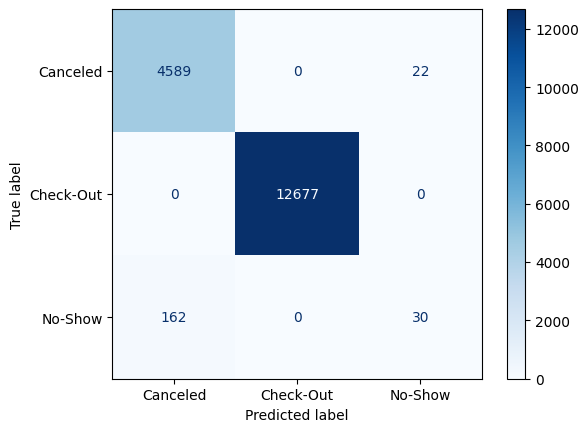

In [81]:
# Generamos la matriz de confusión 
cm_con_nulos_transformados_sin_duplicados = confusion_matrix(y_test_con_nulos_transformados_sin_duplicados, y_pred_con_nulos_transformados_sin_duplicados)
disp_con_nulos_transformados_sin_duplicados = ConfusionMatrixDisplay(confusion_matrix=cm_con_nulos_transformados_sin_duplicados, display_labels=modelo_rl_con_nulos_transformados_sin_duplicados.classes_)
disp_con_nulos_transformados_sin_duplicados.plot(cmap="Blues")

In [82]:
# Evaluacion final



In [85]:
print(f"Accuracy del modelo sinn nulos : {accuracy_sin_nulos:.4f}")
print(f"Accuracy del modelo con nulos transformados: {accuracy_con_nulos_transformados:.4f}")
print(f"Accuracy del modelo sin nulos transformados y sin duplicados: {accuracy_sin_nulos_y_sin_duplicados:.4f}")
print(f"Accuracy del modelo con nulos transformados sin duplicados: {accuracy_con_nulos_transformados_sin_duplicados:.4f}")

Accuracy del modelo sinn nulos : 0.9911
Accuracy del modelo con nulos transformados: 0.9914
Accuracy del modelo sin nulos transformados y sin duplicados: 0.9884
Accuracy del modelo con nulos transformados sin duplicados: 0.9895


# Mejor Modelo

Modelo con nulos transformados